In [1]:
#Full Method

In [ ]:
# import xarray as xr
# import numpy as np

# # ============================================================
# # USER PATHS (KEEP YOUR ORIGINAL PATHS)
# # ============================================================

# # --- f3-L ---
# path_L  = '/data19/wrk/2021zag/Exp_1/2_data15/CMIP6-f3-L_BQ_cmip6hi_amip/06_All_Para_Rdy4TC_Ind/'
# file_L_u = path_L + 'BQ_cmip6hi_amip.famil.20000101.000000.atm_u_ref_6hr.nc'
# file_L_v = path_L + 'BQ_cmip6hi_amip.famil.20000101.000000.atm_v_ref_6hr.nc'

# # --- f3-H ---
# path_H  = '/data19/wrk/2021zag/Exp_1/2_data15/CMIP6-f3-H_BQ_cmip6hi_sg/06_All_Para_Rdy4TC_Ind/'
# file_H_u = path_H + 'BQ_cmip6hi_sg.famil.20000101.000000.atm_u_ref_6hr.nc'
# file_H_v = path_H + 'BQ_cmip6hi_sg.famil.20000101.000000.atm_v_ref_6hr.nc'

# # --- f3-HH ---
# path_HH = '/data19/wrk/2021zag/Exp_2/1_data20/AMIP76-f3_HH_heb/02_AllPara_Ind/2000_2021/'
# file_HH_u = path_HH + 'heb_c768_f02g16_AMIP76.famil.2000.s2s_h.u_ref.nc'
# file_HH_v = path_HH + 'heb_c768_f02g16_AMIP76.famil.2000.s2s_h.v_ref.nc'

# # --- ERA5 ---
# path_ERA  = '/data9/2021zag/ERA5/03_All_Ind/OneSH/'
# file_ERA_u = path_ERA + 'atmos.2000010100-2000123123.u_ref.nc'
# file_ERA_v = path_ERA + 'atmos.2000010100-2000123123.v_ref.nc'


# # ============================================================
# # FUNCTION: KE SPECTRUM
# # ============================================================

# def compute_spectrum(ds_u, ds_v, name_u, name_v, label):
#     print(f"Processing {label}...")

#     # Rename coords if needed
#     if 'latitude' in ds_u.dims:
#         ds_u = ds_u.rename({'latitude': 'lat', 'longitude': 'lon'})
#     if 'latitude' in ds_v.dims:
#         ds_v = ds_v.rename({'latitude': 'lat', 'longitude': 'lon'})

#     u = ds_u[name_u].isel(time=slice(0, 300)).fillna(0.0).values
#     v = ds_v[name_v].isel(time=slice(0, 300)).fillna(0.0).values

#     # Remove zonal mean
#     u = u - np.mean(u, axis=-1, keepdims=True)
#     v = v - np.mean(v, axis=-1, keepdims=True)

#     nt, nlat, nlon = u.shape

#     # FFT
#     fft_u = np.fft.rfft(u, axis=-1)
#     fft_v = np.fft.rfft(v, axis=-1)

#     ke = 0.5 * (np.abs(fft_u)**2 + np.abs(fft_v)**2) / nlon**2

#     # Latitude weighting
#     lat_vals = ds_u.lat.values
#     weights = np.cos(np.deg2rad(lat_vals))[:, np.newaxis]

#     ke_mean = np.mean(ke, axis=0)
#     ke_lat = np.sum(ke_mean * weights, axis=0) / np.sum(weights)

#     k = np.arange(len(ke_lat))

#     # Physical wavelength (km)
#     Re = 6371
#     circumference = 2 * np.pi * Re
#     wavelength = np.zeros_like(k, dtype=float)
#     wavelength[1:] = circumference / k[1:]
#     wavelength[0] = np.nan

#     return k, ke_lat, wavelength


# # ============================================================
# # COMPUTE
# # ============================================================

# ds_L_u = xr.open_dataset(file_L_u)
# ds_L_v = xr.open_dataset(file_L_v)
# k_L, ke_L, wl_L = compute_spectrum(ds_L_u, ds_L_v, 'u_ref', 'v_ref', "f3-L")

# ds_H_u = xr.open_dataset(file_H_u)
# ds_H_v = xr.open_dataset(file_H_v)
# k_H, ke_H, wl_H = compute_spectrum(ds_H_u, ds_H_v, 'u_ref', 'v_ref', "f3-H")

# ds_HH_u = xr.open_dataset(file_HH_u)
# ds_HH_v = xr.open_dataset(file_HH_v)
# k_HH, ke_HH, wl_HH = compute_spectrum(ds_HH_u, ds_HH_v, 'u_ref', 'v_ref', "f3-HH")

# ds_ERA_u = xr.open_dataset(file_ERA_u)
# ds_ERA_v = xr.open_dataset(file_ERA_v)
# k_ERA, ke_ERA, wl_ERA = compute_spectrum(ds_ERA_u, ds_ERA_v, 'u_ref', 'v_ref', "ERA5")


# # ============================================================
# # SAVE (COMPACT + SELF-DESCRIBED)
# # ============================================================

# ds_out = xr.Dataset()

# ds_out["ke_L"]   = xr.DataArray(ke_L, dims=["k_L"], coords={"k_L": k_L})
# ds_out["wl_L"]   = xr.DataArray(wl_L, dims=["k_L"], coords={"k_L": k_L})

# ds_out["ke_H"]   = xr.DataArray(ke_H, dims=["k_H"], coords={"k_H": k_H})
# ds_out["wl_H"]   = xr.DataArray(wl_H, dims=["k_H"], coords={"k_H": k_H})

# ds_out["ke_HH"]  = xr.DataArray(ke_HH, dims=["k_HH"], coords={"k_HH": k_HH})
# ds_out["wl_HH"]  = xr.DataArray(wl_HH, dims=["k_HH"], coords={"k_HH": k_HH})

# ds_out["ke_ERA"] = xr.DataArray(ke_ERA, dims=["k_ERA"], coords={"k_ERA": k_ERA})
# ds_out["wl_ERA"] = xr.DataArray(wl_ERA, dims=["k_ERA"], coords={"k_ERA": k_ERA})

# # Metadata
# ds_out.attrs["description"] = "Zonal KE spectrum (time mean, lat weighted)"
# ds_out.attrs["note"] = "Separate k per model due to different resolutions"

# # Compression
# encoding = {var: {"zlib": True, "complevel": 4} for var in ds_out.data_vars}

# ds_out.to_netcdf("ke_spectrum_summary.nc", encoding=encoding)

# print("Saved: ke_spectrum_summary.nc")

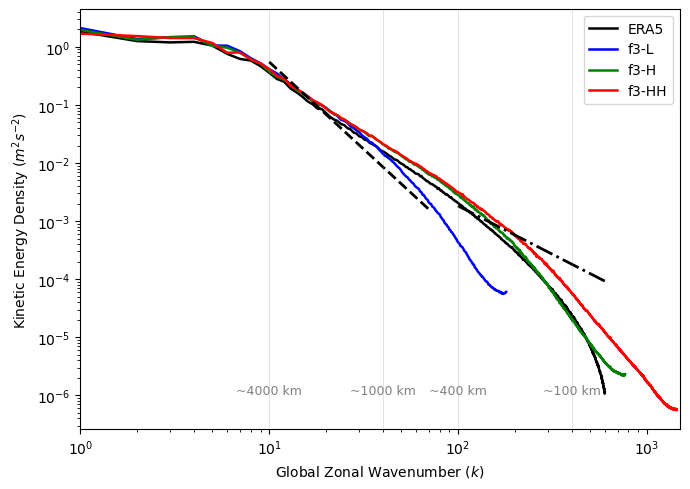

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD
# ============================================================

ds = xr.open_dataset("../Data/KE/ke_spectrum_summary.nc")


# ============================================================
# PLOT FUNCTION
# ============================================================

def plot_model(ax, ds, var, color, label, kmax=None):
    coord_name = list(ds[var].coords)[0]

    k = ds[var][coord_name].values
    ke = ds[var].values

    if kmax is not None:
        mask = k <= kmax
        k = k[mask]
        ke = ke[mask]

    ax.loglog(k[1:], ke[1:], color=color, lw=1.8, label=label)


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7,5))

plot_model(ax, ds, "ke_ERA", "k", "ERA5", kmax=600)
plot_model(ax, ds, "ke_L", "b", "f3-L")
plot_model(ax, ds, "ke_H", "g", "f3-H")
plot_model(ax, ds, "ke_HH", "r", "f3-HH")


# ============================================================
# REFERENCE SLOPES
# ============================================================

k_ref = ds["k_HH"].values
ke_ref = ds["ke_HH"].values

# k^-3
k3 = np.linspace(10, 70, 50)
y3 = ke_ref[15] * (k3 / k_ref[15])**-3
ax.loglog(k3, y3, 'k--', lw=2)

# k^-5/3
k53 = np.linspace(100, 600, 50)
y53 = ke_ref[200] * (k53 / k_ref[200])**(-5/3)
ax.loglog(k53, y53, 'k-.', lw=2)


# ============================================================
# FORMAT
# ============================================================

ax.set_xlabel("Global Zonal Wavenumber ($k$)")
ax.set_ylabel("Kinetic Energy Density ($m^2 s^{-2}$)")
ax.set_xlim(1, 1500)

ax.legend()
ax.grid(True, which="both", ls="-", axis='x', alpha=0.0)


# ============================================================
# WAVELENGTH MARKERS
# ============================================================

wavelengths = [4000, 1000, 400, 100]
k_positions = [40000/w for w in wavelengths]

for kpos, wl in zip(k_positions, wavelengths):
    ax.axvline(kpos, color='gray', lw=0.5, alpha=0.3)
    ax.text(kpos, ax.get_ylim()[0]*4,
            f'~{wl} km',
            ha='center', fontsize=9, color='gray')


plt.tight_layout()
plt.savefig("../Figure/11_KE_spectrum_from_saved.pdf", dpi=300)
plt.show()